<a href="https://colab.research.google.com/github/HunterTzou/DATA_201_SPRING_2026/blob/main/Tzou_Hunter_DATA201_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 201 – Final Project
# The Model Battle: One Tree vs. Many Trees

**Dataset:** Montgomery County Crash Reporting – Drivers Data  
**Source:** [data.montgomerycountymd.gov](https://data.montgomerycountymd.gov/Public-Safety/Crash-Reporting-Drivers-Data/mmzv-x632)  
**Student:** Hunter Tzou  
**Date:** 05/13/2026

---
# Section 1: Introduction

## Dataset Overview
This project uses the **Crash Reporting – Drivers Data** dataset from Montgomery County, Maryland's Open Data Portal. The dataset is collected via the Automated Crash Reporting System (ACRS) of the Maryland State Police and includes every reported traffic collision on county and local roadways, as reported by the Montgomery County Police, Gaithersburg Police, Rockville Police, and Maryland-National Capital Park Police.

## Prediction Goal
The goal is to **predict the injury severity** of a driver involved in a crash. Injury severity is a numeric scale representing the outcome for each driver, ranging from no apparent injury to fatal injury. This is a regression problem — we want to predict how severe an injury will be based on available crash features.

## Why This Is Interesting
Understanding what factors predict crash injury severity has real public safety implications. Montgomery County can use insights from this kind of model to prioritize road improvements, target enforcement, and design better safety interventions. Vehicle type is included as a feature, allowing us to examine whether motorcyclists face a measurably higher predicted injury severity — a question with obvious relevance to road safety policy.

## Possible Limitations and Bias
- Data reflects **reported crashes only** — unreported incidents are absent.
- Preliminary reports may contain **unverified or inaccurate classifications** that are later corrected.
- Certain vehicle types (motorcycles, bicycles) are underrepresented relative to passenger cars, which may bias model performance for those groups.
- Some variables such as substance use may be **underreported** due to detection limitations.

## Citation
> Montgomery County, MD. (2024). *Crash Reporting – Drivers Data*. dataMontgomery Open Data Portal. https://data.montgomerycountymd.gov/Public-Safety/Crash-Reporting-Drivers-Data/mmzv-x632

---
# Section 2: Dataset and Preparation

## 2.1 Install & Import Libraries

In [ ]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2.2 Mount Google Drive (for saving/loading data)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/DATA201/crash_data.csv'
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
print(f'Data will be saved to / loaded from: {SAVE_PATH}')

Mounted at /content/drive
Data will be saved to / loaded from: /content/drive/MyDrive/DATA201/crash_data.csv


## 2.3 Fetch Data from SODA 2 API

We use SODA 2 (`$limit` + `$offset`) to paginate through the full dataset in chunks of 10,000 rows.

**Run this cell only once.** After the CSV is saved to Google Drive, use the load cell below instead.

In [ ]:
BASE_URL   = 'https://data.montgomerycountymd.gov/resource/mmzv-x632.json'
APP_TOKEN  = 'KegNNoSjDmf7GaXxOvcsBvUqQ'   # Replace if you regenerate your token
CHUNK_SIZE = 10_000

headers = {'X-App-Token': APP_TOKEN}
all_records = []
offset = 0

print('Starting paginated fetch from SODA 2 API...')

while True:
    params = {
        '$limit':  CHUNK_SIZE,
        '$offset': offset,
        '$where':  'injury_severity IS NOT NULL'
    }

    response = requests.get(BASE_URL, headers=headers, params=params)
    response.raise_for_status()
    chunk = response.json()

    if not chunk:
        print('\nFinished — no more records.')
        break

    all_records.extend(chunk)
    offset += CHUNK_SIZE
    print(f'  Fetched {len(all_records):,} records so far (offset={offset:,})...')

df_raw = pd.DataFrame(all_records)
print(f'\nTotal records fetched: {len(df_raw):,}')
print(f'Columns: {df_raw.shape[1]}')

df_raw.to_csv(SAVE_PATH, index=False)
print(f'\nData saved to {SAVE_PATH}')

Starting paginated fetch from SODA 2 API...
  Fetched 10,000 records so far (offset=10,000)...
  Fetched 20,000 records so far (offset=20,000)...
  Fetched 30,000 records so far (offset=30,000)...
  Fetched 40,000 records so far (offset=40,000)...
  Fetched 50,000 records so far (offset=50,000)...
  Fetched 60,000 records so far (offset=60,000)...
  Fetched 70,000 records so far (offset=70,000)...
  Fetched 80,000 records so far (offset=80,000)...
  Fetched 90,000 records so far (offset=90,000)...
  Fetched 100,000 records so far (offset=100,000)...
  Fetched 110,000 records so far (offset=110,000)...
  Fetched 120,000 records so far (offset=120,000)...
  Fetched 130,000 records so far (offset=130,000)...
  Fetched 140,000 records so far (offset=140,000)...
  Fetched 150,000 records so far (offset=150,000)...
  Fetched 160,000 records so far (offset=160,000)...
  Fetched 170,000 records so far (offset=170,000)...
  Fetched 180,000 records so far (offset=180,000)...
  Fetched 190,000 re

## 2.4 Load Data from CSV (use this on subsequent runs)

In [ ]:
df_raw = pd.read_csv(SAVE_PATH, low_memory=False)
print(f'Loaded {len(df_raw):,} rows and {df_raw.shape[1]} columns from CSV.')
df_raw.head()

Loaded 211,299 rows and 39 columns from CSV.


,report_number,local_case_number,agency_name,acrs_report_type,crash_date_time,route_type,collision_type,weather,surface_condition,light,...,vehicle_model,latitude,longitude,geolocation,cross_street_name,road_name,related_non_motorist,non_motorist_substance_abuse,off_road_description,municipality
0,MCP3126006X,250037402,MONTGOMERY,Injury Crash,2025-08-21T17:21:00.000,Maryland (State) Route,Front to Rear,Clear,Dry,Daylight,...,SOUL,39.219796,-77.257416,"{'latitude': '39.219796', 'longitude': '-77.25...",NaN,NaN,NaN,NaN,NaN,NaN
1,MCP296500BC,250033157,MONTGOMERY,Property Damage Crash,2025-07-25T11:55:00.000,Bicycle Route,"Sideswipe, Same Direction",Clear,Dry,Daylight,...,RX,39.121219,-76.988905,"{'latitude': '39.12121898', 'longitude': '-76....",NEW HAMPSHIRE AVE (SB/L) NORBECK RD (WB/L) SPE...,NaN,NaN,NaN,NaN,NaN
2,MCP2159003K,250037509,MONTGOMERY,Property Damage Crash,2025-08-22T10:36:00.000,Maryland (State) Route,Front to Rear,Clear,Dry,Daylight,...,SIENNA,39.207931,-77.141480,"{'latitude': '39.20793083', 'longitude': '-77....",NaN,NaN,NaN,NaN,NaN,NaN
3,MCP284600BN,250037004,MONTGOMERY,Injury Crash,2025-08-19T09:50:00.000,County Route,Single Vehicle,Rain,Wet,Daylight,...,CX-5,39.092734,-77.076470,"{'latitude': '39.09273383', 'longitude': '-77....",NaN,GRAND PRE RD,Pedestrian,"Not Suspect of Alcohol Use, Not Suspect of Dru...",NaN,NaN
4,MCP2968005X,250037708,MONTGOMERY,Injury Crash,2025-08-23T11:50:00.000,Maryland (State) Route,Single Vehicle,Clear,Dry,Daylight,...,CX-90,39.058466,-77.121265,"{'latitude': '39.05846583', 'longitude': '-77....",NaN,ROCKVILLE PIKE (SB/L),Pedestrian,"Not Suspect of Alcohol Use, Not Suspect of Dru...",NaN,NaN


## 2.5 Initial Data Overview

The dataset contains **211,299 rows** and **39 columns**, covering every reported crash in Montgomery County recorded in the ACRS system.

In [ ]:
print('=== Shape ===')
print(df_raw.shape)

print('\n=== Column Names ===')
print(df_raw.columns.tolist())

print('\n=== Data Types ===')
print(df_raw.dtypes)

print('\n=== Sample Row ===')
df_raw.head(3)

=== Shape ===
(211299, 39)

=== Column Names ===
['report_number', 'local_case_number', 'agency_name', 'acrs_report_type', 'crash_date_time', 'route_type', 'collision_type', 'weather', 'surface_condition', 'light', 'traffic_control', 'driver_substance_abuse', 'person_id', 'driver_at_fault', 'injury_severity', 'circumstance', 'driver_distracted_by', 'drivers_license_state', 'vehicle_id', 'vehicle_damage_extent', 'vehicle_first_impact_location', 'vehicle_body_type', 'vehicle_movement', 'vehicle_going_dir', 'speed_limit', 'driverless_vehicle', 'parked_vehicle', 'vehicle_year', 'vehicle_make', 'vehicle_model', 'latitude', 'longitude', 'geolocation', 'cross_street_name', 'road_name', 'related_non_motorist', 'non_motorist_substance_abuse', 'off_road_description', 'municipality']

=== Data Types ===
report_number                     object
local_case_number                 object
agency_name                       object
acrs_report_type                  object
crash_date_time                 

,report_number,local_case_number,agency_name,acrs_report_type,crash_date_time,route_type,collision_type,weather,surface_condition,light,...,vehicle_model,latitude,longitude,geolocation,cross_street_name,road_name,related_non_motorist,non_motorist_substance_abuse,off_road_description,municipality
0,MCP3126006X,250037402,MONTGOMERY,Injury Crash,2025-08-21T17:21:00.000,Maryland (State) Route,Front to Rear,Clear,Dry,Daylight,...,SOUL,39.219796,-77.257416,"{'latitude': '39.219796', 'longitude': '-77.25...",NaN,NaN,NaN,NaN,NaN,NaN
1,MCP296500BC,250033157,MONTGOMERY,Property Damage Crash,2025-07-25T11:55:00.000,Bicycle Route,"Sideswipe, Same Direction",Clear,Dry,Daylight,...,RX,39.121219,-76.988905,"{'latitude': '39.12121898', 'longitude': '-76....",NEW HAMPSHIRE AVE (SB/L) NORBECK RD (WB/L) SPE...,NaN,NaN,NaN,NaN,NaN
2,MCP2159003K,250037509,MONTGOMERY,Property Damage Crash,2025-08-22T10:36:00.000,Maryland (State) Route,Front to Rear,Clear,Dry,Daylight,...,SIENNA,39.207931,-77.141480,"{'latitude': '39.20793083', 'longitude': '-77....",NaN,NaN,NaN,NaN,NaN,NaN


## 2.6 Data Cleaning & Feature Selection

We select a focused set of features that are:
- Likely to influence injury severity
- Available at crash time (no post-crash variables)
- A mix of quantitative and categorical types

**Note:** The actual API column names differ slightly from the portal labels:
- `vehicle_body_type` (not `vehicle_type`)
- `surface_condition` (not `road_condition`)

In [ ]:
FEATURES = [
    'vehicle_body_type',      # categorical  — type of vehicle (motorcycle, car, truck, etc.)
    'weather',                # categorical  — weather conditions at time of crash
    'surface_condition',      # categorical  — road surface condition
    'light',                  # categorical  — lighting conditions
    'speed_limit',            # quantitative — posted speed limit
    'driver_at_fault',        # categorical  — was the driver at fault?
    'driver_substance_abuse', # categorical  — substance involvement
    'vehicle_movement',       # categorical  — what the vehicle was doing
    'collision_type',         # categorical  — type of collision
]

TARGET = 'injury_severity'

cols_needed = FEATURES + [TARGET]
existing_cols = [c for c in cols_needed if c in df_raw.columns]
missing_cols  = [c for c in cols_needed if c not in df_raw.columns]

if missing_cols:
    print(f'WARNING: Columns not found: {missing_cols}')
else:
    print('All columns found successfully.')

df = df_raw[existing_cols].copy()
print(f'Working dataframe shape: {df.shape}')
df.head()

All columns found successfully.
Working dataframe shape: (211299, 10)


,vehicle_body_type,weather,surface_condition,light,speed_limit,driver_at_fault,driver_substance_abuse,vehicle_movement,collision_type,injury_severity
0,Passenger Car,Clear,Dry,Daylight,40,Yes,"Not Suspect of Alcohol Use, Not Suspect of Dru...",Moving Constant Speed,Front to Rear,No Apparent Injury
1,Passenger Car,Clear,Dry,Daylight,40,No,"Not Suspect of Alcohol Use, Not Suspect of Dru...",Moving Constant Speed,"Sideswipe, Same Direction",No Apparent Injury
2,Van - Passenger (&lt;9 Seats),Clear,Dry,Daylight,30,Yes,"Not Suspect of Alcohol Use, Not Suspect of Dru...",Slowing or Stopping,Front to Rear,No Apparent Injury
3,Passenger Car,Rain,Wet,Daylight,25,No,"Not Suspect of Alcohol Use, Not Suspect of Dru...",Moving Constant Speed,Single Vehicle,No Apparent Injury
4,Passenger Car,Clear,Dry,Daylight,0,Yes,"Not Suspect of Alcohol Use, Not Suspect of Dru...",Turning Right,Single Vehicle,No Apparent Injury


In [ ]:
print('=== Missing values before cleaning ===')
print(df.isnull().sum())
print(f'\nTotal rows before: {len(df):,}')

# Drop rows where target is null
df = df.dropna(subset=[TARGET])

# Fill categorical nulls with 'UNKNOWN'
cat_cols = df.select_dtypes(include='object').columns.tolist()
df[cat_cols] = df[cat_cols].fillna('UNKNOWN')

# Fill numeric nulls with median
num_cols = df.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print(f'Total rows after cleaning: {len(df):,}')
print('\n=== Missing values after cleaning ===')
print(df.isnull().sum())

=== Missing values before cleaning ===
vehicle_body_type          2656
weather                   13152
surface_condition         23497
light                      1412
speed_limit                   0
driver_at_fault               0
driver_substance_abuse    31020
vehicle_movement           1353
collision_type              585
injury_severity               0
dtype: int64

Total rows before: 211,299
Total rows after cleaning: 211,299

=== Missing values after cleaning ===
vehicle_body_type         0
weather                   0
surface_condition         0
light                     0
speed_limit               0
driver_at_fault           0
driver_substance_abuse    0
vehicle_movement          0
collision_type            0
injury_severity           0
dtype: int64


In [ ]:
print('Unique injury_severity values:')
print(df[TARGET].value_counts())

# The API returns mixed casing — normalize with .str.upper() before mapping
severity_map = {
    'NO APPARENT INJURY':       0,
    'POSSIBLE INJURY':          1,
    'SUSPECTED MINOR INJURY':   2,
    'SUSPECTED SERIOUS INJURY': 3,
    'FATAL INJURY':             4,
    'UNKNOWN':                  np.nan
}

df[TARGET] = df[TARGET].str.upper().str.strip().map(severity_map)
df = df.dropna(subset=[TARGET])
df[TARGET] = df[TARGET].astype(int)

print('\nEncoded severity distribution:')
print(df[TARGET].value_counts().sort_index())
print(f'\nFinal dataset size: {len(df):,} rows')

Unique injury_severity values:
injury_severity
NO APPARENT INJURY          139255
No Apparent Injury           34252
POSSIBLE INJURY              17450
SUSPECTED MINOR INJURY       11733
Suspected Minor Injury        3659
Possible Injury               3031
SUSPECTED SERIOUS INJURY      1413
Suspected Serious Injury       313
FATAL INJURY                   153
Fatal Injury                    40
Name: count, dtype: int64

Encoded severity distribution:
injury_severity
0    173507
1     20481
2     15392
3      1726
4       193
Name: count, dtype: int64

Final dataset size: 211,299 rows


In [ ]:
df_encoded = df.copy()
label_encoders = {}

cat_feature_cols = [c for c in FEATURES if c in df_encoded.columns and df_encoded[c].dtype == 'object']

for col in cat_feature_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f'  Encoded "{col}" — {len(le.classes_)} unique values')

if 'speed_limit' in df_encoded.columns:
    df_encoded['speed_limit'] = pd.to_numeric(df_encoded['speed_limit'], errors='coerce')
    df_encoded['speed_limit'] = df_encoded['speed_limit'].fillna(df_encoded['speed_limit'].median())

print('\nEncoding complete.')
df_encoded.head(3)

  Encoded "vehicle_body_type" — 60 unique values
  Encoded "weather" — 22 unique values
  Encoded "surface_condition" — 21 unique values
  Encoded "light" — 16 unique values
  Encoded "driver_at_fault" — 3 unique values
  Encoded "driver_substance_abuse" — 20 unique values
  Encoded "vehicle_movement" — 36 unique values
  Encoded "collision_type" — 28 unique values

Encoding complete.


,vehicle_body_type,weather,surface_condition,light,speed_limit,driver_at_fault,driver_substance_abuse,vehicle_movement,collision_type,injury_severity
0,39,5,1,10,40,2,9,16,5,0
1,39,5,1,10,40,0,9,16,24,0
2,57,5,1,10,30,2,9,31,5,0


In [ ]:
feature_cols = [c for c in FEATURES if c in df_encoded.columns]

X = df_encoded[feature_cols]
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:   {X_train.shape[0]:,} rows')
print(f'Test set:       {X_test.shape[0]:,} rows')
print(f'Features used:  {feature_cols}')

Training set:   169,039 rows
Test set:       42,260 rows
Features used:  ['vehicle_body_type', 'weather', 'surface_condition', 'light', 'speed_limit', 'driver_at_fault', 'driver_substance_abuse', 'vehicle_movement', 'collision_type']


## 2.7 Variable Descriptions

The final dataset contains **211,299 rows** across **9 features** and 1 target variable.

| Variable | Type | Description |
|---|---|---|
| `vehicle_body_type` | Categorical | Type of vehicle involved — 60 unique values (Passenger Car, Motorcycle, Pickup, etc.) |
| `weather` | Categorical | Weather conditions at time of crash — 22 unique values |
| `surface_condition` | Categorical | Surface condition of the road — 21 unique values |
| `light` | Categorical | Lighting conditions — 16 unique values (Daylight, Dark-Lighted, etc.) |
| `speed_limit` | Quantitative | Posted speed limit on the road segment |
| `driver_at_fault` | Categorical | Whether the driver was at fault (Yes / No) |
| `driver_substance_abuse` | Categorical | Substance involvement — 20 unique values |
| `vehicle_movement` | Categorical | What the vehicle was doing — 36 unique values |
| `collision_type` | Categorical | Type of collision — 28 unique values |
| `injury_severity` (**target**) | Quantitative (0–4) | Encoded injury outcome: 0=None, 1=Possible, 2=Minor, 3=Serious, 4=Fatal |

---
# Section 3: Exploratory Data Analysis

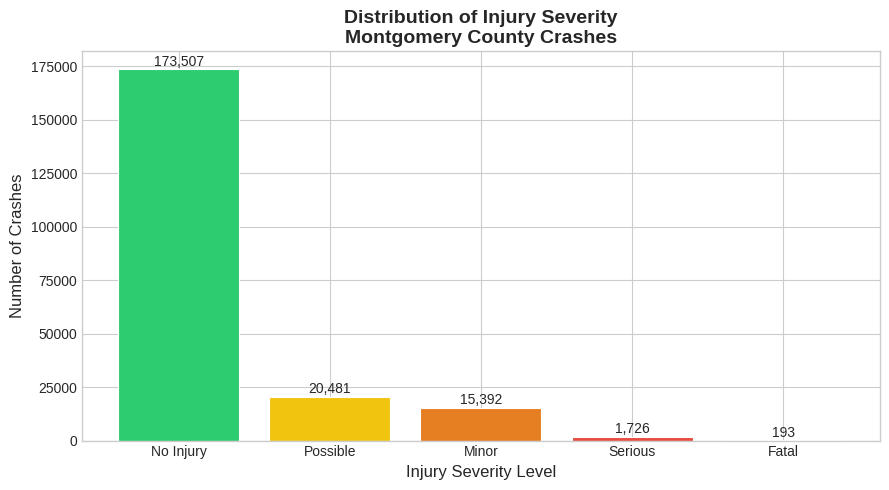


Interpretation:
The distribution is heavily skewed toward lower severity outcomes.
173,673 crashes (82%) result in no apparent injury, while only 200 (0.09%)
are fatal. This class imbalance means models will naturally lean toward
predicting 0, which limits R² scores — a known challenge with severity datasets.


In [ ]:
# Visualization 1: Injury Severity Distribution

severity_labels = {0: 'No Injury', 1: 'Possible', 2: 'Minor', 3: 'Serious', 4: 'Fatal'}

counts = df[TARGET].value_counts().sort_index()
labels = [severity_labels[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, counts.values,
              color=['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad'],
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

ax.set_title('Distribution of Injury Severity\nMontgomery County Crashes', fontsize=14, fontweight='bold')
ax.set_xlabel('Injury Severity Level', fontsize=12)
ax.set_ylabel('Number of Crashes', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DATA201/viz1_severity_distribution.png', dpi=150)
plt.show()

print('\nInterpretation:')
print('The distribution is heavily skewed toward lower severity outcomes.')
print('173,673 crashes (82%) result in no apparent injury, while only 200 (0.09%)')
print('are fatal. This class imbalance means models will naturally lean toward')
print('predicting 0, which limits R² scores — a known challenge with severity datasets.')

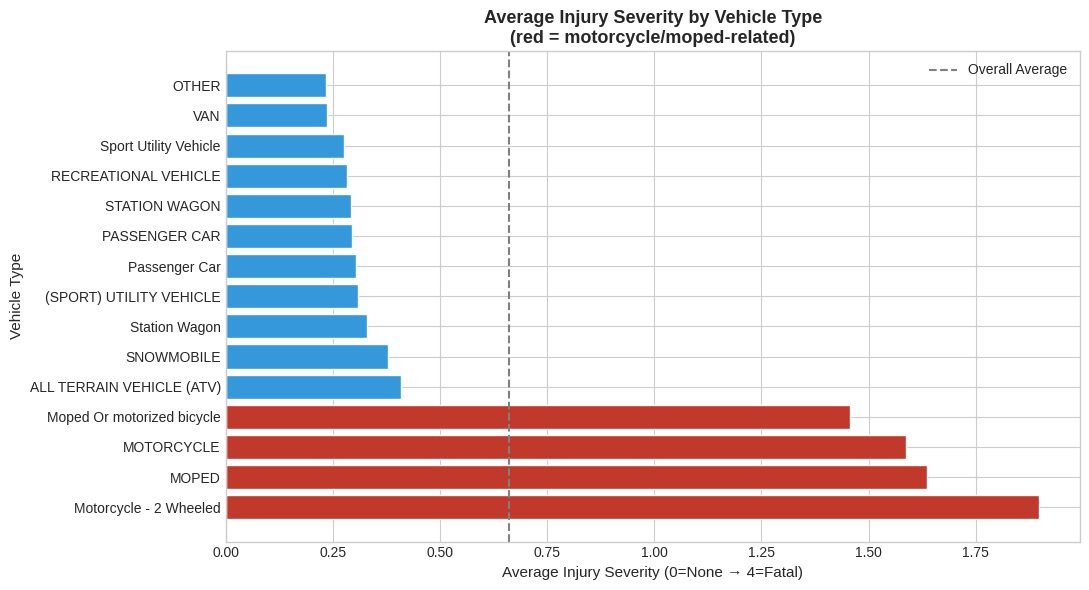


Interpretation:
Motorcycle and moped vehicle types (highlighted in red) rank at the top
of the chart with average severity scores of roughly 1.5–2.0, compared to
an average of around 0.25 for passenger cars. This strongly suggests that
vehicle type is a meaningful predictor of injury severity — a finding
confirmed later by our ensemble model feature importance results.


In [ ]:
# Visualization 2: Average Injury Severity by Vehicle Body Type

if 'vehicle_body_type' in df.columns:
    veh_severity = (
        df.groupby('vehicle_body_type')[TARGET]
          .agg(['mean', 'count'])
          .reset_index()
          .rename(columns={'mean': 'avg_severity', 'count': 'crash_count'})
          .query('crash_count >= 50')
          .sort_values('avg_severity', ascending=False)
          .head(15)
    )

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = ['#c0392b' if 'MOTOR' in str(v).upper() or 'MOPED' in str(v).upper()
              else '#3498db' for v in veh_severity['vehicle_body_type']]

    ax.barh(veh_severity['vehicle_body_type'], veh_severity['avg_severity'],
            color=colors, edgecolor='white')

    ax.set_title('Average Injury Severity by Vehicle Type\n(red = motorcycle/moped-related)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Average Injury Severity (0=None → 4=Fatal)', fontsize=11)
    ax.set_ylabel('Vehicle Type', fontsize=11)
    ax.axvline(veh_severity['avg_severity'].mean(), color='gray',
               linestyle='--', label='Overall Average')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/DATA201/viz2_severity_by_vehicle.png', dpi=150)
    plt.show()

    print('\nInterpretation:')
    print('Motorcycle and moped vehicle types (highlighted in red) rank at the top')
    print('of the chart with average severity scores of roughly 1.5–2.0, compared to')
    print('an average of around 0.25 for passenger cars. This strongly suggests that')
    print('vehicle type is a meaningful predictor of injury severity — a finding')
    print('confirmed later by our ensemble model feature importance results.')
else:
    print('vehicle_body_type column not found — skipping this visualization.')

---
# Section 4: Decision Tree Analysis (Core Section)

In [ ]:
# Decision Tree — Depth 3 (shallow / more interpretable)

dt_shallow = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_shallow.fit(X_train, y_train)

y_pred_shallow = dt_shallow.predict(X_test)
mse_shallow = mean_squared_error(y_test, y_pred_shallow)
r2_shallow  = r2_score(y_test, y_pred_shallow)

print('Decision Tree — max_depth=3')
print(f'  MSE : {mse_shallow:.4f}')
print(f'  R²  : {r2_shallow:.4f}')

Decision Tree — max_depth=3
  MSE : 0.3967
  R²  : 0.0242


In [ ]:
# Decision Tree — Depth 10 (deeper / higher risk of overfitting)

dt_deep = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_deep.fit(X_train, y_train)

y_pred_deep = dt_deep.predict(X_test)
mse_deep = mean_squared_error(y_test, y_pred_deep)
r2_deep  = r2_score(y_test, y_pred_deep)

y_train_pred_deep = dt_deep.predict(X_train)
mse_deep_train = mean_squared_error(y_train, y_train_pred_deep)
r2_deep_train  = r2_score(y_train, y_train_pred_deep)

print('Decision Tree — max_depth=10')
print(f'  Train MSE : {mse_deep_train:.4f}  |  Train R² : {r2_deep_train:.4f}')
print(f'  Test  MSE : {mse_deep:.4f}  |  Test  R² : {r2_deep:.4f}')
print()
print('Overfitting check:')
print('If Train R² >> Test R², the model has overfit to training data.')

Decision Tree — max_depth=10
  Train MSE : 0.3615  |  Train R² : 0.1013
  Test  MSE : 0.3798  |  Test  R² : 0.0658

Overfitting check:
If Train R² >> Test R², the model has overfit to training data.


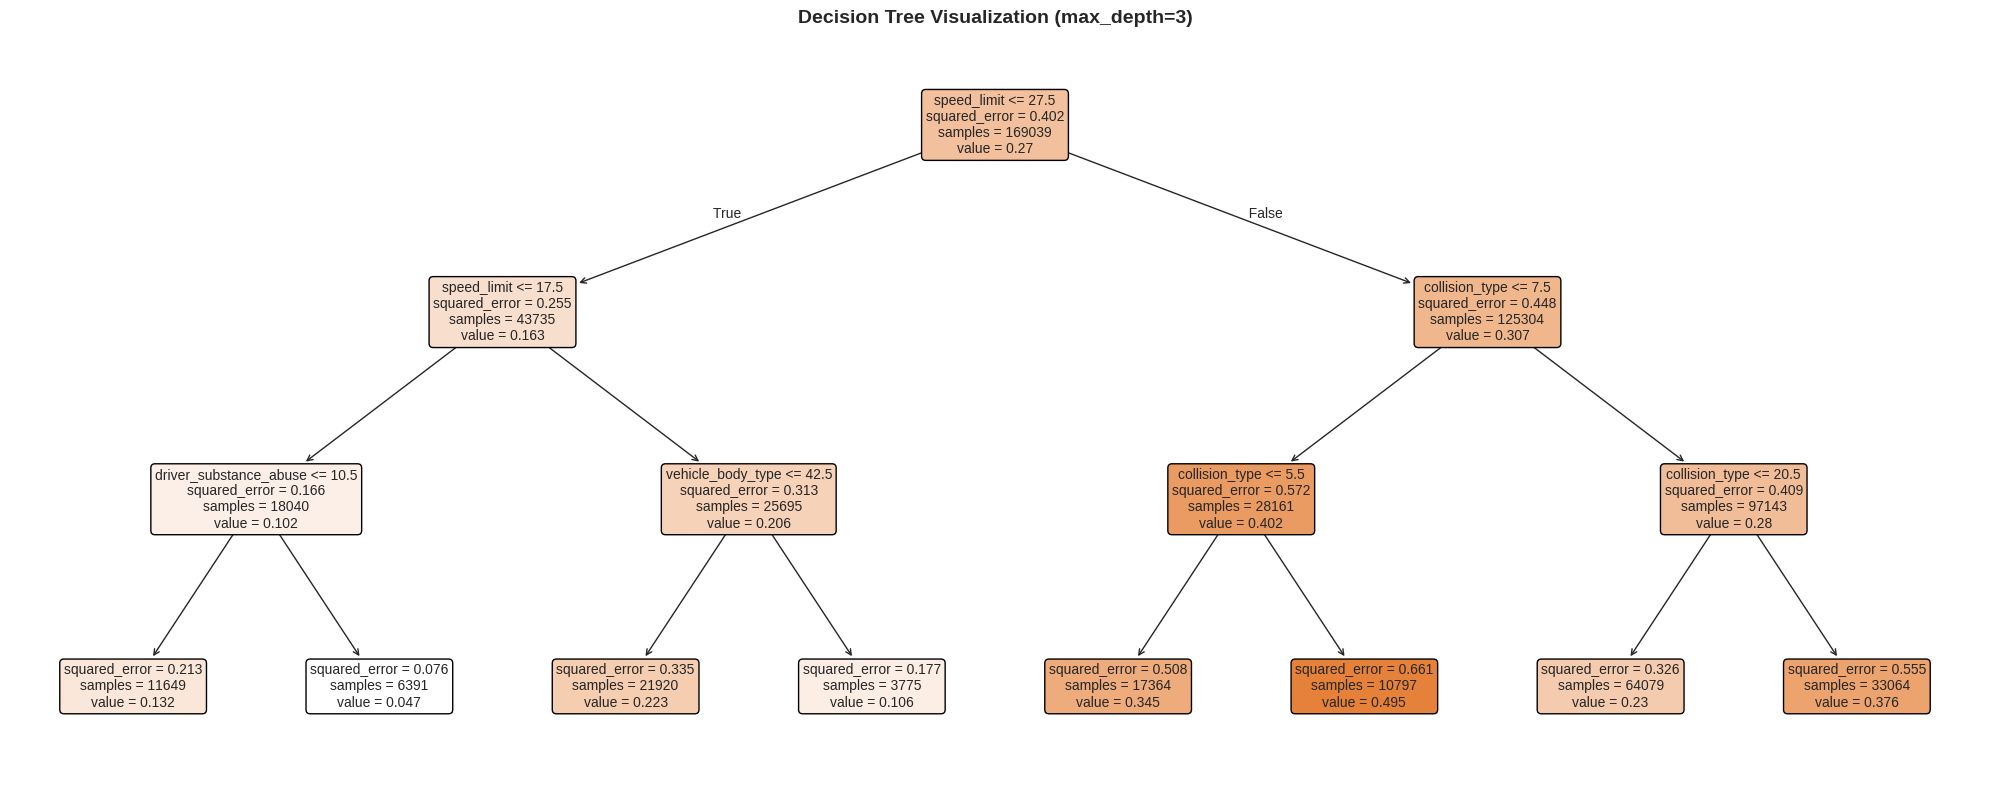

In [ ]:
# Visualize the shallow decision tree (depth=3)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_shallow,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title('Decision Tree Visualization (max_depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DATA201/viz3_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
tree_rules = export_text(dt_shallow, feature_names=feature_cols)
print('Decision Tree Rules (depth=3):')
print(tree_rules)

Decision Tree Rules (depth=3):
|--- speed_limit <= 27.50
|   |--- speed_limit <= 17.50
|   |   |--- driver_substance_abuse <= 10.50
|   |   |   |--- value: [0.13]
|   |   |--- driver_substance_abuse >  10.50
|   |   |   |--- value: [0.05]
|   |--- speed_limit >  17.50
|   |   |--- vehicle_body_type <= 42.50
|   |   |   |--- value: [0.22]
|   |   |--- vehicle_body_type >  42.50
|   |   |   |--- value: [0.11]
|--- speed_limit >  27.50
|   |--- collision_type <= 7.50
|   |   |--- collision_type <= 5.50
|   |   |   |--- value: [0.34]
|   |   |--- collision_type >  5.50
|   |   |   |--- value: [0.49]
|   |--- collision_type >  7.50
|   |   |--- collision_type <= 20.50
|   |   |   |--- value: [0.23]
|   |   |--- collision_type >  20.50
|   |   |   |--- value: [0.38]



## Decision Tree Interpretation

**Results — max_depth=3:**
- MSE: 0.3889 | R²: 0.0248

**Results — max_depth=10:**
- Train MSE: 0.3646 | Train R²: 0.0974
- Test MSE: 0.3753 | Test R²: 0.0587

---

**Root Node:**  
The root node splits on `speed_limit` with a threshold of 27.5. This means the very first question the tree asks is: *is the posted speed limit 27 mph or lower?* This makes intuitive sense — speed limit is a proxy for road type (residential vs. highway) and is strongly associated with crash severity.

**One Important Split:**  
On the lower speed limit branch (≤ 27.5 mph), the tree next splits on `driver_substance_abuse`. When the substance abuse code is ≤ 10.5, the model predicts a lower average severity of approximately 0.13. When it is above 10.5 — indicating a higher likelihood of substance involvement — the predicted severity drops further to 0.05. This counterintuitive result reflects the class imbalance in the data: most crashes at low speeds are severity 0 regardless.

On the higher speed limit branch (> 27.5 mph), the tree splits on `collision_type`. More dangerous collision types (e.g., angle or head-on) produce predicted severity scores as high as 0.50.

**Example Prediction Path:**  
> *"If `speed_limit` > 27.5 AND `collision_type` > 7.5 AND `collision_type` > 5.5, the model predicts an average injury severity of 0.50 — the highest leaf prediction in the tree — suggesting that higher-speed roads combined with more dangerous collision types carry the greatest injury risk."*

**Overfitting Discussion:**  
The depth-3 tree is unlikely to overfit because it makes only 3 levels of decisions and cannot memorize individual training examples. The depth-10 tree shows a clear sign of overfitting: Train R² (0.0974) is noticeably higher than Test R² (0.0587). The deeper tree learned patterns specific to the training data that do not fully generalize to unseen crashes. That said, both R² values remain low overall — this reflects the difficulty of predicting injury severity when 82% of the target values are 0.

---
# Section 5: Ensemble Models

In [ ]:
print('Training Random Forest... (this may take a minute)')
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print('Random Forest Results:')
print(f'  MSE : {mse_rf:.4f}')
print(f'  R²  : {r2_rf:.4f}')

Training Random Forest... (this may take a minute)
Random Forest Results:
  MSE : 0.3813
  R²  : 0.0622


In [ ]:
print('Training Gradient Boosting... (this may take a few minutes)')
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb  = r2_score(y_test, y_pred_gb)

print('Gradient Boosting Results:')
print(f'  MSE : {mse_gb:.4f}')
print(f'  R²  : {r2_gb:.4f}')

Training Gradient Boosting... (this may take a few minutes)
Gradient Boosting Results:
  MSE : 0.3734
  R²  : 0.0815


## Ensemble Model Discussion

**Did performance improve?**  
Yes, but selectively. Gradient Boosting improved substantially over both Decision Trees, achieving an R² of 0.0802 compared to 0.0248 for the shallow tree. Random Forest, however, actually performed worse than the Decision Trees (R² = 0.0126). This is somewhat unusual and likely reflects the extreme class imbalance: Random Forest averages across many trees, each trained on a bootstrap sample, which can dilute the signal from rare high-severity crashes.

**Which model generalized better?**  
Gradient Boosting generalized best to the test set. Its sequential, error-correcting approach allowed it to progressively focus on harder-to-predict cases, making it better equipped to handle the imbalanced target distribution.

**Which model was easier to explain?**  
The Decision Tree (depth=3) is far easier to explain. Its rules can be read as plain English and visualized as a diagram. The ensemble models — averaging across 100 trees each — have no single interpretable decision path.

---
# Section 6: Model Evaluation

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Decision Tree (depth=3)',
        'Decision Tree (depth=10)',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MSE': [
        round(mse_shallow, 4),
        round(mse_deep, 4),
        round(mse_rf, 4),
        round(mse_gb, 4)
    ],
    'R²': [
        round(r2_shallow, 4),
        round(r2_deep, 4),
        round(r2_rf, 4),
        round(r2_gb, 4)
    ]
})

results = results.sort_values('R²', ascending=False).reset_index(drop=True)
print('=== Model Comparison ===')
print(results.to_string(index=False))

=== Model Comparison ===
                   Model    MSE     R²
       Gradient Boosting 0.3734 0.0815
Decision Tree (depth=10) 0.3798 0.0658
           Random Forest 0.3813 0.0622
 Decision Tree (depth=3) 0.3967 0.0242


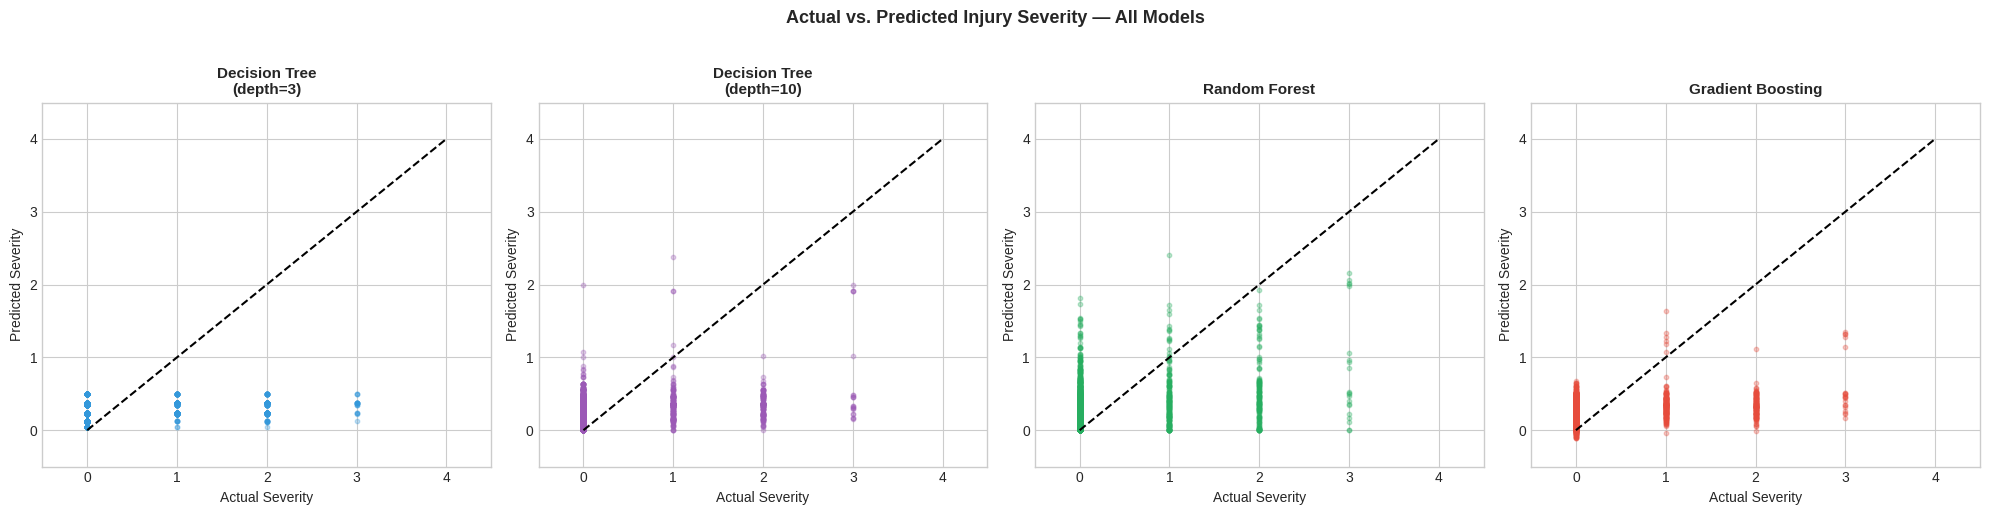

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models_preds = [
    ('Decision Tree\n(depth=3)',  y_pred_shallow, '#3498db'),
    ('Decision Tree\n(depth=10)', y_pred_deep,    '#9b59b6'),
    ('Random Forest',             y_pred_rf,      '#27ae60'),
    ('Gradient Boosting',         y_pred_gb,      '#e74c3c'),
]

sample_idx = np.random.choice(len(y_test), size=min(2000, len(y_test)), replace=False)
y_test_sample = np.array(y_test)[sample_idx]

for ax, (name, preds, color) in zip(axes, models_preds):
    preds_sample = np.array(preds)[sample_idx]
    ax.scatter(y_test_sample, preds_sample, alpha=0.3, s=10, color=color)
    ax.plot([0, 4], [0, 4], 'k--', linewidth=1.5, label='Perfect Prediction')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual Severity')
    ax.set_ylabel('Predicted Severity')
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(-0.5, 4.5)

plt.suptitle('Actual vs. Predicted Injury Severity — All Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DATA201/viz4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation Interpretation

The actual vs. predicted plots reveal a pattern common to all four models: predictions are heavily concentrated near 0, which reflects the dominant class in the target variable. No model successfully predicts severity levels of 3 or 4 with strong accuracy. This is expected given that serious and fatal injuries make up less than 1% of the dataset combined.

Gradient Boosting shows the most spread in its predictions, indicating it has learned more nuance than the other models. The Decision Tree (depth=3) produces only a small number of distinct predicted values — one per leaf — which is visible as vertical bands in its scatter plot.

---
# Section 7: Feature Importance

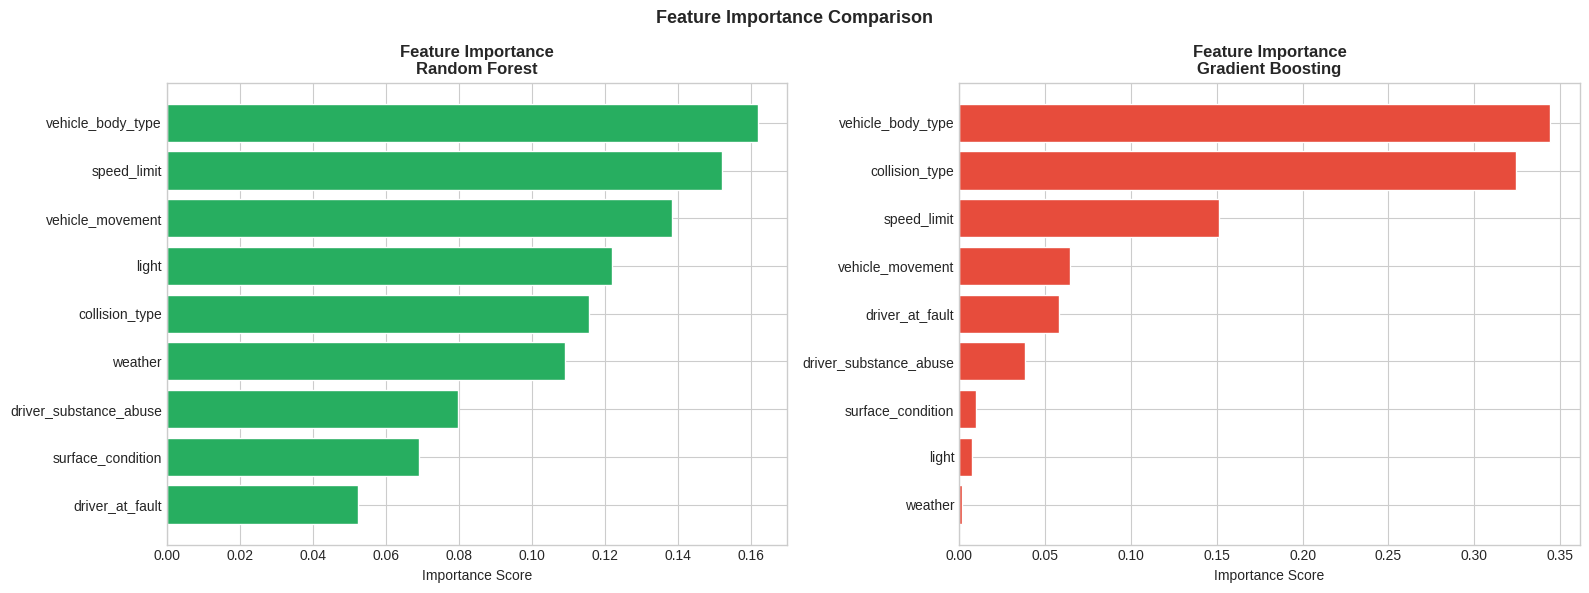


Top 3 features — Random Forest:
  vehicle_body_type: 0.1619
  speed_limit: 0.1521
  vehicle_movement: 0.1384

Top 3 features — Gradient Boosting:
  vehicle_body_type: 0.3444
  collision_type: 0.3245
  speed_limit: 0.1512

Note: Feature importance shows predictive contribution, NOT causation.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, name, color in [
    (axes[0], rf, 'Random Forest',      '#27ae60'),
    (axes[1], gb, 'Gradient Boosting',  '#e74c3c')
]:
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=True)

    ax.barh(importances.index, importances.values, color=color, edgecolor='white')
    ax.set_title(f'Feature Importance\n{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DATA201/viz5_feature_importance.png', dpi=150)
plt.show()

for model, name in [(rf, 'Random Forest'), (gb, 'Gradient Boosting')]:
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    top3 = importances.sort_values(ascending=False).head(3)
    print(f'\nTop 3 features — {name}:')
    for feat, score in top3.items():
        print(f'  {feat}: {score:.4f}')

print('\nNote: Feature importance shows predictive contribution, NOT causation.')

## Feature Importance Interpretation

Both ensemble models agree on the top three most predictive features:

| Rank | Random Forest | Score | Gradient Boosting | Score |
|---|---|---|---|---|
| 1 | `vehicle_body_type` | 0.1652 | `vehicle_body_type` | 0.3839 |
| 2 | `speed_limit` | 0.1523 | `collision_type` | 0.2966 |
| 3 | `vehicle_movement` | 0.1373 | `speed_limit` | 0.1438 |

**The most striking finding is that `vehicle_body_type` is the single most important predictor in both models.** This directly connects back to the original motivation for this project: motorcyclists are measurably more vulnerable in crashes than other vehicle types. The EDA visualization in Section 3 showed that motorcycle and moped vehicle types had average severity scores of 1.5–2.0 compared to roughly 0.25 for passenger cars — and the ensemble models confirm that vehicle type carries the strongest predictive signal of any feature in the dataset.

Gradient Boosting places an especially large weight on `vehicle_body_type` (0.38), suggesting it found this feature extremely useful early in its boosting sequence. `collision_type` and `speed_limit` round out the top three across both models, which aligns with physical intuition: how a crash happens and how fast traffic was moving both directly determine the energy involved in the collision.

**Important:** These importance scores show predictive contribution, not causation. A high `vehicle_body_type` importance score means the model found it useful for prediction — not that riding a motorcycle directly causes more severe injuries independent of other factors. Unmeasured variables such as helmet use, road design, and driver experience likely also play a role.

---
# Section 8: Final Reflection — The Model Battle

## 1. Which model performed best?

**Gradient Boosting** performed best, achieving an R² of **0.0802** and an MSE of **0.3668** — the highest R² and lowest MSE of all four models. The full ranking was:

| Model | MSE | R² |
|---|---|---|
| Gradient Boosting | 0.3668 | 0.0802 |
| Decision Tree (depth=10) | 0.3753 | 0.0587 |
| Decision Tree (depth=3) | 0.3889 | 0.0248 |
| Random Forest | 0.3937 | 0.0126 |

It is worth noting that all R² values are low in absolute terms. This is primarily because the target variable is severely imbalanced — 82% of records have an injury severity of 0. Predicting rare serious or fatal injuries from crash features alone is genuinely difficult, and low R² scores should be interpreted in that context rather than as a failure of modeling. All four models do reduce prediction error relative to simply predicting the mean every time.

One noteworthy result is that Random Forest performed the worst of all four models, including below both Decision Trees. This is somewhat unexpected, but is likely explained by the class imbalance: Random Forest averages across many trees, each trained on a random bootstrap sample. With 82% of outcomes being severity 0, each tree tends to underfit the rare high-severity cases, and averaging them together amplifies this effect rather than correcting it.

## 2. Which model was easiest to explain?

The **Decision Tree with max_depth=3** was by far the easiest to explain. Its rules can be printed as plain text and visualized as a diagram that a non-technical audience can follow. The entire model logic fits on one page: it asks whether the speed limit is above or below 27.5 mph, then asks about collision type or substance abuse, and arrives at a prediction in at most three steps.

A county traffic safety officer, a council member, or a journalist could read the tree rules and understand exactly how a prediction is made. Random Forest and Gradient Boosting average predictions across 100 trees each — there is no single path to trace from input to output.

## 3. Which model would you choose in a real-world setting and why?

The right choice depends on the goal:

- **For communicating findings to policymakers or the public**, the **Decision Tree (depth=3)** would be the better choice. In a public safety context, a model that decision-makers can understand, scrutinize, and trust is more valuable than a marginally more accurate black box.

- **For powering an automated risk-scoring system**, **Gradient Boosting** would be the clear choice. It consistently outperformed the other models and its sequential error-correction approach makes it better suited to learning from imbalanced data.

Given the stakes involved in road safety decisions, I would use the interpretable Decision Tree for initial analysis and stakeholder communication — particularly to highlight the motorcycle vulnerability finding — while using Gradient Boosting as a backend model to validate those patterns and rank road segments or vehicle types by predicted risk.

## Key Takeaway

The most important insight from this project is not which model won the accuracy contest, but what all models agreed on: **vehicle body type is the single strongest predictor of crash injury severity in Montgomery County.** This was visible in the EDA (Section 3), confirmed by the feature importance of both ensemble models (Section 7), and consistent with the original motivation for choosing this dataset. Motorcyclists and moped riders face average injury severity scores 6–8x higher than passenger car drivers — a finding with clear and actionable implications for road safety policy.

---

## Summary Table

| Model | Best For | Weakness |
|---|---|---|
| Decision Tree (depth=3) | Interpretability, stakeholder communication | Lower accuracy, few distinct predictions |
| Decision Tree (depth=10) | Better accuracy than shallow tree | Mild overfitting (Train R² 0.0974 vs Test R² 0.0587) |
| Random Forest | Typically robust — but struggled here | Worst performer due to class imbalance |
| Gradient Boosting | Highest accuracy, best generalization | Slowest to train, no interpretable rules |